# GAT-Based Cell Clustering: Transfer Learning for scRNA-Seq

**Approach:** Train an unsupervised Graph Attention Network (GAT) autoencoder on two scRNA-seq datasets (Zeisel, Pollen), then transfer the learned weights to cluster a held-out dataset (Klein) and compare against KMeans and SC3 baselines.

| Dataset | Accession | Cells | Source | Role |
|---------|-----------|-------|--------|------|
| Zeisel | GSE60361 | 3,005 | Mouse Cerebral Cortex | Training |
| Pollen | GSE59739 | ~300 | Human Tissue/Neural | Training |
| Klein | GSE65525 | ~2,700 | Mouse Embryonic Stem Cells | Demo/Transfer |
| Semrau | GSE79578 | 3,456 | Mouse Embryonic Stem Cells | Training | 


In [1]:
# ============================================================
# Section 1: Setup
# ============================================================

import copy
import gzip
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sc3s
import scanpy as sc
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATConv

INPUT_DIR = Path("data/input")
INPUT_DIR.mkdir(parents=True, exist_ok=True)

random_state = 5

def fetch_file(url: str, dest: Path):
    if not dest.exists() or dest.stat().st_size == 0:
        print(f"Downloading {dest.name}...")
        urllib.request.urlretrieve(url, dest)
        print(f"  Done: {dest.stat().st_size / 1e6:.1f} MB")
    else:
        print(f"Already have {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")


c:\Users\Hersh\Documents\class\ds677\final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading

Download all four datasets from GEO into `data/input/`.


In [2]:
# ============================================================
# Load Zeisel (GSE60361) - Training set 1
# ============================================================
def load_Zeisel():
    zeisel_expr_path = INPUT_DIR / "GSE60361_C1-3005-Expression.txt"
    zeisel_labels_path = INPUT_DIR / "Zeisel_cell_label.csv"

    # Expression file is large (115MB) - must be manually placed or downloaded separately
    if not zeisel_expr_path.exists():
        print("NOTE: GSE60361 expression file too large for auto-download.")
        print("Place GSE60361_C1-3005-Expression.txt in data/input/")
    else:
        expr_df = pd.read_csv(zeisel_expr_path, sep="\t", index_col=0)
        zeisel_adata = sc.AnnData(
            X=expr_df.T.values.astype(np.float32),
            obs=pd.DataFrame(index=expr_df.columns),
            var=pd.DataFrame(index=expr_df.index)
        )
        zeisel_adata.obs_names_make_unique()
        zeisel_adata.var_names_make_unique()

        # Attach labels
        if zeisel_labels_path.exists():
            labels_df = pd.read_csv(zeisel_labels_path, index_col=0)
            zeisel_adata.obs["cell_type"] = labels_df.reindex(zeisel_adata.obs_names)["Label"].values.astype(str)

        print(f"Zeisel: {zeisel_adata.n_obs} cells x {zeisel_adata.n_vars} genes")
        print(f"Labels: {zeisel_adata.obs['cell_type'].value_counts().to_dict()}")
        return zeisel_adata
        
zeisel_adata = load_Zeisel()


Zeisel: 3005 cells x 19972 genes
Labels: {'3': 939, '4': 820, '2': 399, '1': 290, '6': 235, '7': 224, '5': 98}


c:\Users\Hersh\Documents\class\ds677\final_project\.venv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
# ============================================================
# Load Pollen (GSE59739) - Training set 3
# ============================================================

def load_pollen():
    pollen_expr_path = INPUT_DIR / "GSE59739_DataTable.txt.gz"
    base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE59nnn/GSE59739"
    fetch_file(f"{base_url}/suppl/GSE59739_DataTable.txt.gz", pollen_expr_path)

    pollen_matrices = []
    for gpl in ["GPL11002", "GPL13112"]:
        mat_file = INPUT_DIR / f"GSE59739-{gpl}_series_matrix.txt.gz"
        fetch_file(f"{base_url}/matrix/{mat_file.name}", mat_file)
        pollen_matrices.append(mat_file)

    # Parse metadata
    meta_dfs = []
    for mat_file in pollen_matrices:
        sample_ids, cell_names, characteristics = [], [], {}
        with gzip.open(mat_file, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if line.startswith("!Sample_geo_accession"):
                    sample_ids = [x.strip('" \n') for x in line.split('\t')[1:]]
                elif line.startswith("!Sample_title"):
                    cell_names = [x.strip('" \n') for x in line.split('\t')[1:]]
                elif line.startswith("!Sample_characteristics_ch1"):
                    vals = [x.strip('" \n') for x in line.split('\t')[1:]]
                    if vals and ":" in vals[0]:
                        key = vals[0].split(":")[0].strip()
                        characteristics[key] = [v.split(":", 1)[-1].strip() for v in vals]
                elif line.startswith("!series_matrix_table_begin"):
                    break
        df = pd.DataFrame(characteristics, index=sample_ids)
        if cell_names and len(cell_names) == len(df):
            df["cell_name"] = cell_names
        meta_dfs.append(df)

    pollen_meta = pd.concat(meta_dfs)

    # Load expression
    raw_expr = pd.read_csv(pollen_expr_path, sep="\t", index_col=0, compression="gzip", low_memory=False).T
    numeric_cols = raw_expr.apply(lambda col: pd.to_numeric(col, errors='coerce')).notna().all()
    clean_expr = raw_expr.loc[:, numeric_cols].astype(float)

    pollen_adata = sc.AnnData(
        X=clean_expr.values,
        obs=pollen_meta.reindex(clean_expr.index),
        var=pd.DataFrame(index=clean_expr.columns)
    )
    pollen_adata.obs_names_make_unique()
    pollen_adata.var_names_make_unique()
    print(f"Pollen: {pollen_adata.n_obs} cells x {pollen_adata.n_vars} genes")
    print(f"Metadata: {list(pollen_adata.obs.columns)}")
    
    return pollen_adata

pollen_adata = load_pollen()

Already have GSE59739_DataTable.txt.gz (11.5 MB)
Already have GSE59739-GPL11002_series_matrix.txt.gz (0.0 MB)
Already have GSE59739-GPL13112_series_matrix.txt.gz (0.0 MB)
Pollen: 864 cells x 25333 genes
Metadata: ['cell picking session', 'cell picking temperature', 'strain', 'gender', 'cell_name']


In [4]:
# ============================================================
# Load Klein (GSE65525) - Demo/Transfer target
# ============================================================

def load_Klein():
    klein_tar = INPUT_DIR / "GSE65525_RAW.tar"
    klein_dir = INPUT_DIR / "GSE65525_extracted"

    fetch_file("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE65525&format=file", klein_tar)

    if not klein_dir.exists():
        klein_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(klein_tar, "r") as tar:
            tar.extractall(path=klein_dir)

    dfs, obs_data = [], {}
    mouse_files = sorted([
        f for f in klein_dir.glob("*GSM159949*")
        if f.name.endswith(('.csv', '.csv.gz', '.csv.bz2'))
    ])

    for i, filepath in enumerate(mouse_files):
        df_t = pd.read_csv(filepath, index_col=0).T
        df_t.index = [f"b{i}_{cid}" for cid in df_t.index]
        stage = filepath.name.split("_")[2] if len(filepath.name.split("_")) > 2 else "unknown"
        for cid in df_t.index:
            obs_data[cid] = stage
        dfs.append(df_t)

    expr_df = pd.concat(dfs)
    klein_adata = sc.AnnData(
        X=expr_df.values.astype(float),
        obs=pd.DataFrame({"cell_stage": obs_data}),
        var=pd.DataFrame(index=expr_df.columns)
    )
    klein_adata.var_names_make_unique()
    print(f"Klein: {klein_adata.n_obs} cells x {klein_adata.n_vars} genes")
    print(f"Stages: {klein_adata.obs['cell_stage'].value_counts().to_dict()}")
    
    return klein_adata

klein_adata = load_Klein()

Already have GSE65525_RAW.tar (47.1 MB)
Klein: 8669 cells x 24174 genes
Stages: {'d0': 6885, 'd7': 798, 'd4': 683, 'd2': 303}


In [5]:
# ============================================================
# Load Semrau (GSE79578) - 4th Training Set
# ============================================================
def load_Semrau():
    semrau_tar = INPUT_DIR / "GSE79578_RAW.tar"
    semrau_dir = INPUT_DIR / "GSE79578_extracted"

    # 1. Download & Extract
    fetch_file("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE79578&format=file", semrau_tar)

    if not semrau_dir.exists():
        semrau_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(semrau_tar, "r") as tar:
            tar.extractall(path=semrau_dir)

    # 2. Parse valid single-cell files
    valid_exts = ('.csv', '.csv.gz', '.txt', '.txt.gz', '.tsv', '.tsv.gz')
    mouse_files = sorted([
        f for f in semrau_dir.iterdir() 
        if f.name.endswith(valid_exts) and 'bulk' not in f.name.lower()
    ])

    dfs = []
    for i, filepath in enumerate(mouse_files):
        sep = '\t' if '.txt' in filepath.name or '.tsv' in filepath.name else ','
        
        # Read, remove NaNs, remove duplicate genes, and transpose
        df = pd.read_csv(filepath, index_col=0, sep=sep, low_memory=False)
        df = df[df.index.notna()]
        df = df[~df.index.duplicated(keep='first')].T
        
        # Prefix cell barcodes to prevent overlap between batches
        df.index = [f"b{i}_{cid}" for cid in df.index]
        
        # Add metadata directly as a column to the dataframe
        parts = filepath.name.split(".")[0].split("_")
        df['cell_stage'] = parts[2] if len(parts) > 2 else (parts[1] if len(parts) > 1 else "unknown")
        
        dfs.append(df)

    # 3. Concatenate all batches (fills missing genes with 0 automatically)
    full_df = pd.concat(dfs).fillna(0)

    # 4. Build AnnData (Handling European decimal formatting)
    # Isolate the numeric expression matrix
    numeric_df = full_df.drop(columns='cell_stage')

    # FIX: Replace European commas with standard decimal periods (e.g. 4,23E-03 -> 4.23E-03)
    numeric_df = numeric_df.replace(',', '.', regex=True)

    semrau_adata = sc.AnnData(
        X=numeric_df.values.astype(float),
        obs=full_df[['cell_stage']].copy(),
        var=pd.DataFrame(index=numeric_df.columns)
    )

    print(f"Semrau: {semrau_adata.n_obs} cells x {semrau_adata.n_vars} genes")
    print(f"Stages:\n{semrau_adata.obs['cell_stage'].value_counts().to_string()}")
    return semrau_adata

semrau_adata = load_Semrau() 

Already have GSE79578_RAW.tar (17.8 MB)
Semrau: 3795 cells x 23951 genes
Stages:
cell_stage
24h    473
12h    470
2i     466
48h    466
6h     384
36h    384
60h    384
72h    384
96h    384


## 3. Exploratory Analysis

Confirm gene overlap across datasets — we need a shared gene space for the transfer approach to work.


In [6]:
# ============================================================
# Gene overlap analysis
# ============================================================

datasets = {
    "Zeisel": zeisel_adata, 
    "Pollen": pollen_adata, 
    "Semrau": semrau_adata, 
    "Klein": klein_adata
}

# Pairwise overlap matrix
names = list(datasets.keys())
gene_sets = {n: set(d.var_names) for n, d in datasets.items()}

print("Dataset dimensions:")
for n, d in datasets.items():
    print(f"  {n:8s}: {d.n_obs:5d} cells x {d.n_vars:6d} genes")

# Shared genes across all 4 datasets
shared_genes = gene_sets["Zeisel"] & gene_sets["Pollen"] & gene_sets["Semrau"] & gene_sets["Klein"]
print(f"\nShared genes (all 4 datasets): {len(shared_genes)}")

# Shared across training sets only (Zeisel, Pollen, Semrau)
train_shared = gene_sets["Zeisel"] & gene_sets["Pollen"] & gene_sets["Semrau"]
print(f"Shared genes (3 training sets only): {len(train_shared)}")

# Pairwise gene overlap table
print("\nPairwise gene overlap:")
overlap_matrix = pd.DataFrame(index=names, columns=names, dtype=int)
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        overlap_matrix.loc[n1, n2] = len(gene_sets[n1] & gene_sets[n2])
print(overlap_matrix)

# Verdict
print(f"\n--- Transfer Feasibility ---")
if len(shared_genes) > 2000:
    print(f"GOOD: {len(shared_genes)} genes shared across all 4 — plenty for shared PCA space")
elif len(shared_genes) > 500:
    print(f"MARGINAL: {len(shared_genes)} shared genes — might work with careful feature selection")
else:
    print(f"POOR: only {len(shared_genes)} shared genes — transfer unlikely to work well")

Dataset dimensions:
  Zeisel  :  3005 cells x  19972 genes
  Pollen  :   864 cells x  25333 genes
  Semrau  :  3795 cells x  23951 genes
  Klein   :  8669 cells x  24174 genes

Shared genes (all 4 datasets): 18377
Shared genes (3 training sets only): 18603

Pairwise gene overlap:
         Zeisel   Pollen   Semrau    Klein
Zeisel  19972.0  18809.0  19612.0  19373.0
Pollen  18809.0  25333.0  21973.0  21630.0
Semrau  19612.0  21973.0  23951.0  23533.0
Klein   19373.0  21630.0  23533.0  24174.0

--- Transfer Feasibility ---
GOOD: 18377 genes shared across all 4 — plenty for shared PCA space


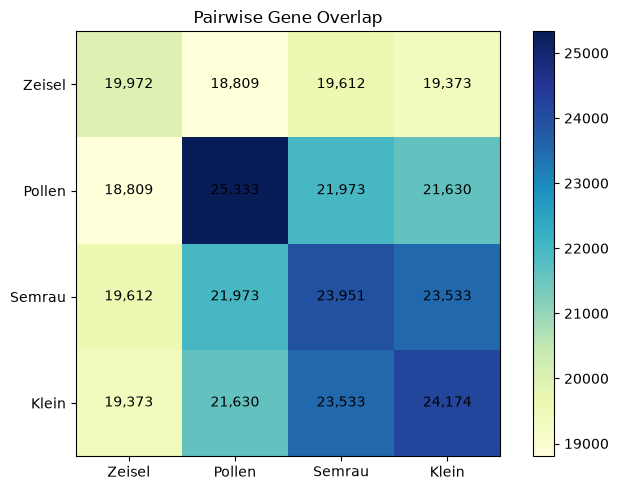


Using 18377 shared genes as the common feature space for all datasets.


In [7]:
# Visualize overlap as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
overlap_arr = overlap_matrix.values.astype(int)
im = ax.imshow(overlap_arr, cmap="YlGnBu")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{overlap_arr[i,j]:,}", ha="center", va="center", fontsize=10)
ax.set_title("Pairwise Gene Overlap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nUsing {len(shared_genes)} shared genes as the common feature space for all datasets.")


## 4. Shared Gene Space + Preprocessing

Subset all datasets to shared genes, normalize, and compute PCA in a common space. The PCA is fit on the training data and applied (transformed) to Klein.


In [10]:
# ============================================================
# Subset to shared genes, normalize, PCA
# ============================================================

shared_genes_sorted = sorted(shared_genes)
N_PCS = 50

# Subset each dataset to shared genes
def subset_and_normalize(adata, genes):
    """Subset to shared genes, normalize, log-transform."""
    sub = adata[:, adata.var_names.isin(genes)].copy()
    sub = sub[:, shared_genes_sorted].copy()
    sc.pp.filter_cells(sub, min_genes=10)
    sub.layers["counts"] = sub.X.copy()
    sc.pp.normalize_total(sub)
    sc.pp.log1p(sub)
    return sub

zeisel_sub = subset_and_normalize(zeisel_adata, shared_genes)
pollen_sub = subset_and_normalize(pollen_adata, shared_genes)
semrau_sub = subset_and_normalize(semrau_adata, shared_genes)
klein_sub = subset_and_normalize(klein_adata, shared_genes)

print("After subsetting to shared genes + normalization:")
for name, sub in [("Zeisel", zeisel_sub), ("Pollen", pollen_sub), ("Semrau", semrau_sub), ("Klein", klein_sub)]:
    print(f"  {name:8s}: {sub.n_obs} cells x {sub.n_vars} genes")

# Fit PCA on training data (Zeisel + Pollen + Semrau combined)
train_X = np.vstack([
    zeisel_sub.X if not hasattr(zeisel_sub.X, 'toarray') else zeisel_sub.X.toarray(),
    pollen_sub.X if not hasattr(pollen_sub.X, 'toarray') else pollen_sub.X.toarray(),
    semrau_sub.X if not hasattr(semrau_sub.X, 'toarray') else semrau_sub.X.toarray()
])
print(f"\nTraining PCA on combined train data: {train_X.shape}")

# Standardize before PCA
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)

pca = PCA(n_components=N_PCS, random_state=random_state)
pca.fit(train_X_scaled)
print(f"Variance explained by {N_PCS} PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Transform all datasets
def get_pca_embedding(adata):
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    return pca.transform(scaler.transform(X))

zeisel_pca = get_pca_embedding(zeisel_sub)
pollen_pca = get_pca_embedding(pollen_sub)
semrau_pca = get_pca_embedding(semrau_sub)
klein_pca = get_pca_embedding(klein_sub)

print(f"\nPCA embeddings:")
print(f"  Zeisel: {zeisel_pca.shape}")
print(f"  Pollen: {pollen_pca.shape}")
print(f"  Semrau: {semrau_pca.shape}")
print(f"  Klein:  {klein_pca.shape}")

After subsetting to shared genes + normalization:
  Zeisel  : 3005 cells x 18377 genes
  Pollen  : 863 cells x 18377 genes
  Semrau  : 3795 cells x 18377 genes
  Klein   : 8669 cells x 18377 genes

Training PCA on combined train data: (7663, 18377)
Variance explained by 50 PCs: 25.9%

PCA embeddings:
  Zeisel: (3005, 50)
  Pollen: (863, 50)
  Semrau: (3795, 50)
  Klein:  (8669, 50)


In [11]:
# Going back to the exploratory analysis, see sparsity of the datasets

for name, sub in [("Zeisel", zeisel_sub), ("Pollen", pollen_sub), ("Semrau", semrau_sub), ("Klein", klein_sub)]:
    X = sub.X if not hasattr(sub.X, 'toarray') else sub.X.toarray()
    print(f"{name:8s}: {(X == 0).mean()*100:.1f}% zeros")

Zeisel  : 80.8% zeros
Pollen  : 83.2% zeros
Semrau  : 89.7% zeros
Klein   : 66.9% zeros


## 5. GAT Training

Train the unsupervised GAT autoencoder on the combined training data (Zeisel + Pollen). The model learns to refine PCA embeddings by aggregating information from KNN neighbors.


In [12]:
# ============================================================
# GAT Autoencoder definition
# ============================================================

class GATAutoencoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, embed_dim, heads=4, dropout_rate = 0.3):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout_rate)
        self.gat2 = GATConv(hidden_dim * heads, embed_dim, heads=1, dropout=dropout_rate)
        self.decoder = torch.nn.Linear(embed_dim, in_dim)

    def encode(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        h = F.dropout(h, p=self.dropout_rate, training=self.training)
        h = self.gat2(h, edge_index)
        return h

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        x_recon = self.decoder(z)
        return x_recon, z


def build_knn_graph(embeddings, k=15):
    knn = NearestNeighbors(n_neighbors=min(k, len(embeddings)-1), metric="euclidean")
    knn.fit(embeddings)
    _, indices = knn.kneighbors(embeddings)
    src, dst = [], []
    for i in range(len(embeddings)):
        for j in indices[i]:
            if i != j:
                src.append(i)
                dst.append(j)
    return torch.tensor([src, dst], dtype=torch.long)


print("GAT architecture defined.")


GAT architecture defined.


In [13]:
# Combine training PCA embeddings into one graph
train_pca_combined = np.vstack([zeisel_pca, pollen_pca, semrau_pca])
print(f"Combined embeddings: {train_pca_combined.shape}")

# Build KNN graph on combined training data
edge_index = build_knn_graph(train_pca_combined, k=15)
x_all = torch.tensor(np.ascontiguousarray(train_pca_combined), dtype=torch.float32)
print(f"Full graph: {x_all.shape[0]} nodes, {edge_index.shape[1]} edges")

# Create Train/Val Split Indices (80% Train, 20% Val)
np.random.seed(random_state) # For reproducibility
num_nodes = x_all.shape[0]
indices = np.random.permutation(num_nodes)
split_point = int(num_nodes * 0.8)

train_idx = torch.tensor(indices[:split_point], dtype=torch.long)
val_idx = torch.tensor(indices[split_point:], dtype=torch.long)
print(f"Split: {len(train_idx)} training nodes, {len(val_idx)} validation nodes")

Combined embeddings: (7663, 50)
Full graph: 7663 nodes, 107282 edges
Split: 6130 training nodes, 1533 validation nodes


Combined embeddings: (7663, 50)
Full graph: 7663 nodes, 107282 edges
  Epoch   0 | Train Loss: 136.92393 | Val Loss: 95.77242
  Epoch  50 | Train Loss: 27.94982 | Val Loss: 26.12845
  Epoch 100 | Train Loss: 21.83275 | Val Loss: 20.36302
  Epoch 150 | Train Loss: 19.15791 | Val Loss: 18.91464
  Epoch 200 | Train Loss: 16.76372 | Val Loss: 18.41421
  Epoch 250 | Train Loss: 18.56390 | Val Loss: 17.90358
  Epoch 300 | Train Loss: 16.46337 | Val Loss: 17.84274
  Epoch 350 | Train Loss: 16.91771 | Val Loss: 17.58255
  Epoch 400 | Train Loss: 15.83383 | Val Loss: 17.60364
  Epoch 450 | Train Loss: 15.99548 | Val Loss: 17.65014
  Epoch 500 | Train Loss: 14.18963 | Val Loss: 17.46429
  Epoch 550 | Train Loss: 16.93690 | Val Loss: 17.39047
  Epoch 600 | Train Loss: 16.21055 | Val Loss: 17.35224
  Epoch 650 | Train Loss: 16.38545 | Val Loss: 17.58951
  Epoch 700 | Train Loss: 14.75987 | Val Loss: 17.54201
  Epoch 750 | Train Loss: 15.16252 | Val Loss: 17.31530
  Epoch 799 | Train Loss: 14.72583

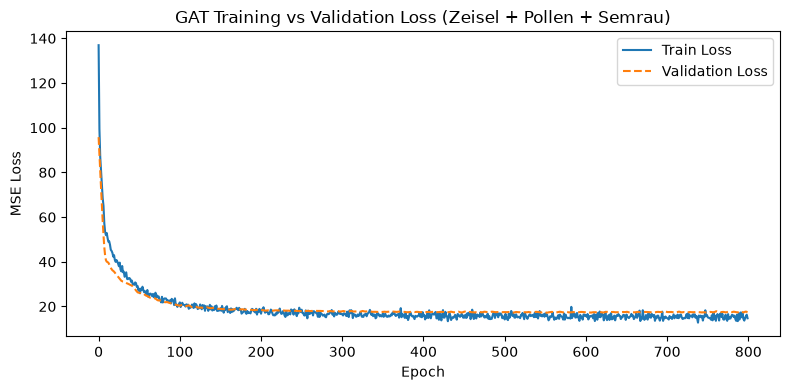


Training complete. Model has 23,506 parameters.
Restored model weights from epoch with lowest Validation Loss (17.24240).


In [ ]:
# ============================================================
# Train GAT on combined training data with Validation Split (CPU)
# ============================================================

# Combine training PCA embeddings into one graph
train_pca_combined = np.vstack([zeisel_pca, pollen_pca, semrau_pca])
print(f"Combined embeddings: {train_pca_combined.shape}")

# Build KNN graph on combined training data
edge_index = build_knn_graph(train_pca_combined, k=15)
x_all = torch.tensor(np.ascontiguousarray(train_pca_combined), dtype=torch.float32)
print(f"Full graph: {x_all.shape[0]} nodes, {edge_index.shape[1]} edges")

# Create Train/Val Split Indices (80% Train, 20% Val)
np.random.seed(42) # For reproducibility
num_nodes = x_all.shape[0]
indices = np.random.permutation(num_nodes)
split_point = int(num_nodes * 0.8)

train_idx = torch.tensor(indices[:split_point], dtype=torch.long)
val_idx = torch.tensor(indices[split_point:], dtype=torch.long)

# Init model
HIDDEN_DIM = 64
EMBED_DIM = 32
EPOCHS = 800
LR = 0.005

# Saving dir
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model = GATAutoencoder(in_dim=N_PCS, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, heads=4, dropout_rate=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Track best model parameters based on VALIDATION loss
best_val_loss = float('inf')
best_model_path = MODEL_DIR / "best_gat_model.pth"

train_losses = []
val_losses = []

# Train Loop
for epoch in range(EPOCHS):
    # 1. Training Phase
    model.train()
    
    # zero the parameter gradients
    optimizer.zero_grad(set_to_none=True)
    
    # Forward pass on the whole graph
    x_recon, z = model(x_all, edge_index)
    
    # Calculate loss ONLY on training nodes
    loss = F.mse_loss(x_recon[train_idx], x_all[train_idx])
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    # 2. Validation Phase
    model.eval() # Turn off dropout for validation
    with torch.no_grad(): # Turn off gradient tracking to save time
        val_recon, _ = model(x_all, edge_index)
        
        # Calculate loss ONLY on validation nodes
        val_loss = F.mse_loss(val_recon[val_idx], x_all[val_idx])
        current_val_loss = val_loss.item()
        val_losses.append(current_val_loss)

    # Save the model if validation loss improves
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), best_model_path)

    # Print progress
    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d} | Train Loss: {loss.item():.5f} | Val Loss: {current_val_loss:.5f}")

# Restore the model to the best saved weights (based on validation)
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set to evaluation mode for subsequent transfer tasks

# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GAT Training vs Validation Loss (Zeisel + Pollen + Semrau)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTraining complete. Model has {sum(p.numel() for p in model.parameters()):,} parameters.")
print(f"Restored model weights from epoch with lowest Validation Loss ({best_val_loss:.5f}).")

## 6. Transfer to Klein

Apply the frozen GAT weights to Klein's PCA embeddings. Build Klein's own KNN graph, run the trained encoder — no further training.


In [15]:
# ============================================================
# Apply trained GAT to Klein (frozen weights)
# ============================================================

# Build Klein's own KNN graph
klein_edge_index = build_knn_graph(klein_pca, k=15)
x_klein = torch.tensor(np.ascontiguousarray(klein_pca), dtype=torch.float32)
print(f"Klein graph: {x_klein.shape[0]} nodes, {klein_edge_index.shape[1]} edges")

# Run frozen encoder
model.eval()
with torch.no_grad():
    _, klein_gat_embeddings = model(x_klein, klein_edge_index)
    klein_gat_embeddings = klein_gat_embeddings.numpy()

print(f"Klein GAT embeddings (transferred): {klein_gat_embeddings.shape}")

# Also get training set embeddings for reference
with torch.no_grad():
    _, all_train_gat = model(x_all, edge_index)
    all_train_gat = all_train_gat.numpy()

# Split back into individual training datasets
n_zeisel = len(zeisel_pca)
n_pollen = len(pollen_pca)

zeisel_gat = all_train_gat[:n_zeisel]
pollen_gat = all_train_gat[n_zeisel : n_zeisel + n_pollen]
semrau_gat = all_train_gat[n_zeisel + n_pollen:]
print(f"Training embeddings: Zeisel={zeisel_gat.shape}, Pollen={pollen_gat.shape}")


Klein graph: 8669 nodes, 121366 edges
Klein GAT embeddings (transferred): (8669, 32)
Training embeddings: Zeisel=(3005, 32), Pollen=(863, 32)


## 7. Evaluation — Baselines + Comparison

Cluster Klein with KMeans (on raw PCA), SC3, and KMeans (on GAT-refined embeddings). Compare ARI against known cell stages.


In [16]:
# ============================================================
# Clustering on Klein — all methods
# ============================================================

true_klein = klein_sub.obs["cell_stage"] if "cell_stage" in klein_sub.obs else klein_adata.obs["cell_stage"]
k_values = [4, 8, 10]

# Attach PCA to AnnData so SC3 can find it
klein_sub.obsm["X_pca"] = np.ascontiguousarray(klein_pca)

# KMeans on raw PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    klein_sub.obs[f"kmeans_k{k}"] = km.fit_predict(klein_pca).astype(str)

# KMeans on GAT embeddings (transferred)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    klein_sub.obs[f"gat_k{k}"] = km.fit_predict(klein_gat_embeddings).astype(str)

# SC3
print("Running SC3 on Klein...")
sc3s.tl.consensus(klein_sub, n_clusters=k_values)

# Results
print("\n--- Klein ARI Comparison (vs cell_stage) ---")
print(f"{'k':<4} {'KMeans (PCA)':<16} {'SC3':<16} {'GAT (Transfer)':<16}")
print("-" * 52)
for k in k_values:
    km_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"kmeans_k{k}"])
    sc3_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"sc3s_{k}"])
    gat_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"gat_k{k}"])
    print(f"{k:<4} {km_ari:<16.4f} {sc3_ari:<16.4f} {gat_ari:<16.4f}")


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30


Running SC3 on Klein...


INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)



--- Klein ARI Comparison (vs cell_stage) ---
k    KMeans (PCA)     SC3              GAT (Transfer)  
----------------------------------------------------
4    0.2546           0.2957           0.2441          
8    0.1360           0.0758           0.0999          
10   0.0970           0.0888           0.1035          


... storing 'cell_stage' as categorical
... storing 'kmeans_k4' as categorical
... storing 'kmeans_k8' as categorical
... storing 'kmeans_k10' as categorical
... storing 'gat_k4' as categorical
... storing 'gat_k8' as categorical
... storing 'gat_k10' as categorical


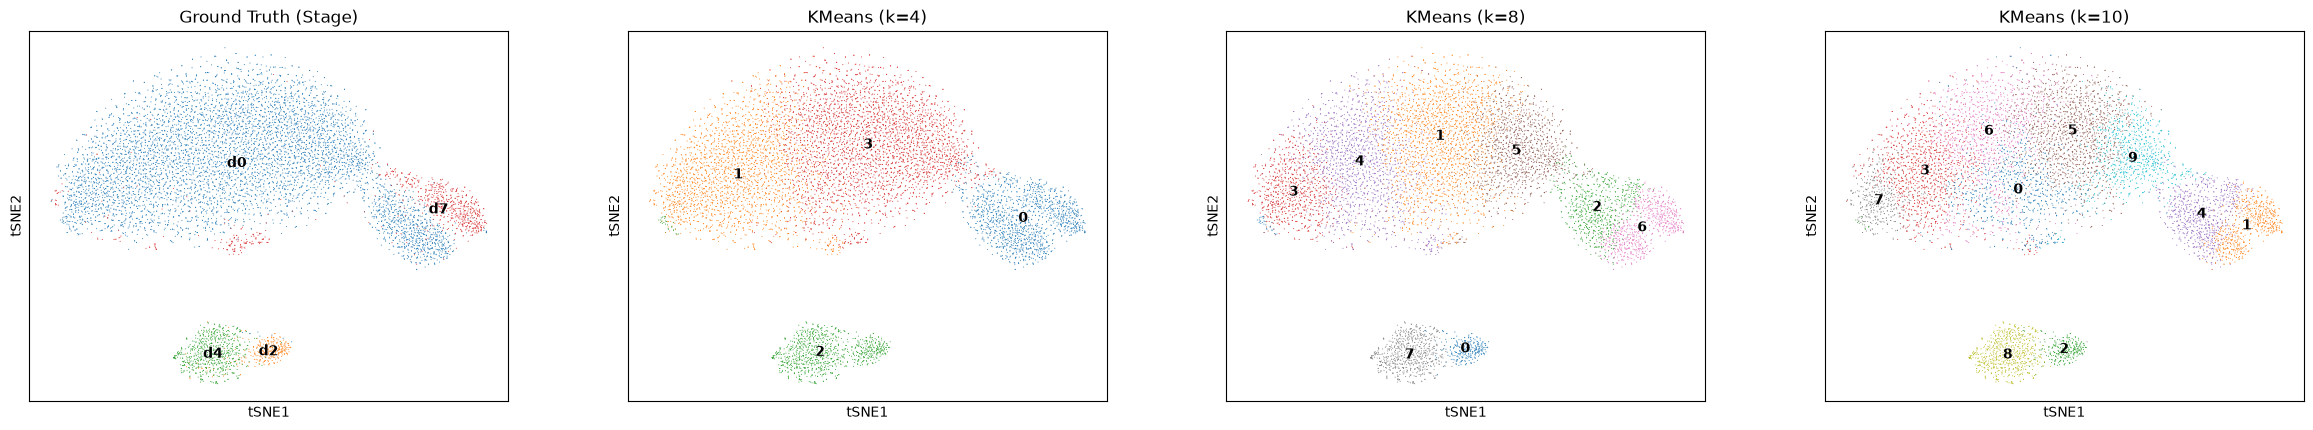

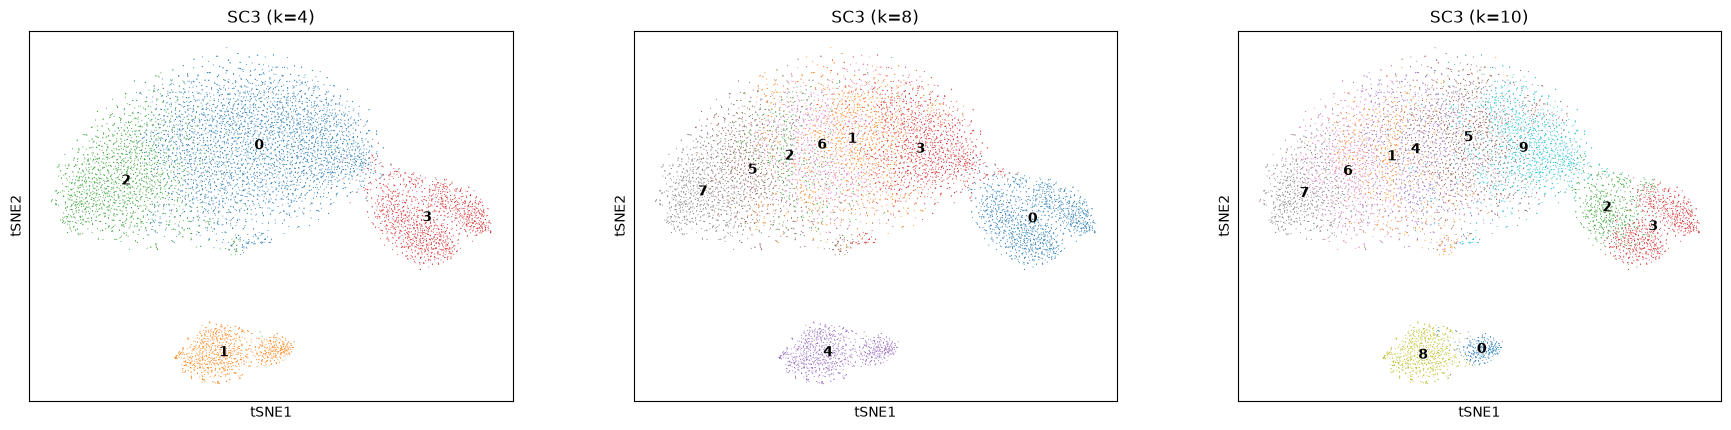

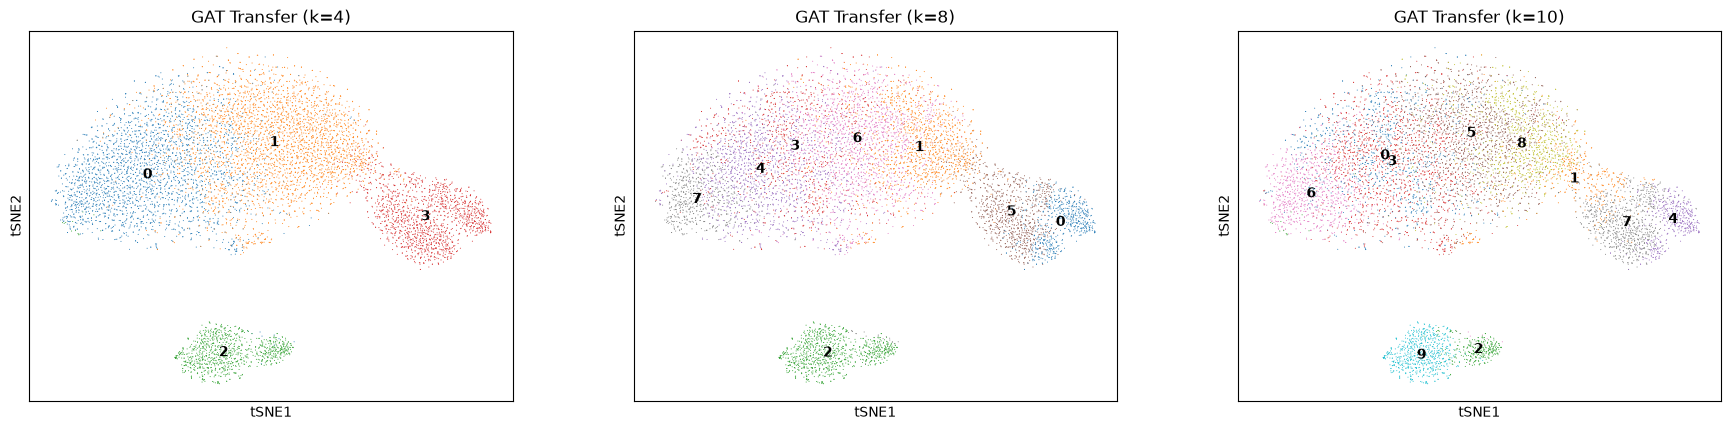

In [17]:
# ============================================================
# Visualize Klein clustering (clean) — all three methods side by side
# ============================================================

# Need t-SNE coords for Klein - compute from our shared PCA
klein_sub.obsm["X_pca"] = np.ascontiguousarray(klein_pca)
sc.tl.tsne(klein_sub, n_pcs=50)

# Row 1: Ground truth + KMeans at k=4,8,10
sc.pl.tsne(
    klein_sub,
    color=["cell_stage"] + [f"kmeans_k{k}" for k in k_values],
    ncols=4, size=2, legend_loc="on data",
    title=["Ground Truth (Stage)"] + [f"KMeans (k={k})" for k in k_values]
)

# Row 2: SC3 at k=4,8,10
sc.pl.tsne(
    klein_sub,
    color=[f"sc3s_{k}" for k in k_values],
    ncols=3, size=2, legend_loc="on data",
    title=[f"SC3 (k={k})" for k in k_values]
)

# Row 3: GAT transfer at k=4,8,10
sc.pl.tsne(
    klein_sub,
    color=[f"gat_k{k}" for k in k_values],
    ncols=3, size=2, legend_loc="on data",
    title=[f"GAT Transfer (k={k})" for k in k_values]
)


In [18]:
# ============================================================
# Dropout robustness test on Klein
# ============================================================

dropout_rate = 0.15
np.random.seed(random_state)

# Inject dropouts into Klein's raw counts
klein_noisy = klein_sub.copy()
counts = klein_noisy.layers["counts"].copy()
non_zero = counts > 0
keep = np.random.binomial(1, 1 - dropout_rate, size=counts.shape).astype(bool)
counts[non_zero & ~keep] = 0
klein_noisy.X = counts

# Re-normalize + PCA in same shared space
sc.pp.normalize_total(klein_noisy)
sc.pp.log1p(klein_noisy)
X_noisy = klein_noisy.X if not hasattr(klein_noisy.X, 'toarray') else klein_noisy.X.toarray()
klein_noisy_pca = pca.transform(scaler.transform(X_noisy))

# KMeans on noisy PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    klein_noisy.obs[f"kmeans_k{k}"] = km.fit_predict(klein_noisy_pca).astype(str)

# GAT transfer on noisy
klein_noisy_edge = build_knn_graph(klein_noisy_pca, k=15)
x_noisy = torch.tensor(np.ascontiguousarray(klein_noisy_pca), dtype=torch.float32)
with torch.no_grad():
    _, klein_noisy_gat = model(x_noisy, klein_noisy_edge)
    klein_noisy_gat = klein_noisy_gat.numpy()

for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    klein_noisy.obs[f"gat_k{k}"] = km.fit_predict(klein_noisy_gat).astype(str)

# SC3 on noisy
klein_noisy.obsm["X_pca"] = np.ascontiguousarray(klein_noisy_pca)
sc3s.tl.consensus(klein_noisy, n_clusters=k_values)

# Final comparison
print("=" * 60)
print("KLEIN — Clean vs Noisy (15% dropout) ARI Comparison")
print("=" * 60)
print(f"\n{'k':<4} {'Method':<18} {'Clean':<10} {'Noisy':<10} {'Degradation':<12}")
print("-" * 54)
for k in k_values:
    for method, col in [("KMeans (PCA)", f"kmeans_k{k}"), ("SC3", f"sc3s_{k}"), ("GAT (Transfer)", f"gat_k{k}")]:
        clean_ari = adjusted_rand_score(true_klein, klein_sub.obs[col])
        noisy_ari = adjusted_rand_score(true_klein, klein_noisy.obs[col])
        deg = clean_ari - noisy_ari
        print(f"{k:<4} {method:<18} {clean_ari:<10.4f} {noisy_ari:<10.4f} {deg:+.4f}")
    print()


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30
INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)


KLEIN — Clean vs Noisy (15% dropout) ARI Comparison

k    Method             Clean      Noisy      Degradation 
------------------------------------------------------
4    KMeans (PCA)       0.2546     0.2544     +0.0002
4    SC3                0.2957     0.1329     +0.1628
4    GAT (Transfer)     0.2441     0.2446     -0.0005

8    KMeans (PCA)       0.1360     0.1395     -0.0035
8    SC3                0.0758     0.0811     -0.0053
8    GAT (Transfer)     0.0999     0.0941     +0.0059

10   KMeans (PCA)       0.0970     0.1057     -0.0087
10   SC3                0.0888     0.0682     +0.0206
10   GAT (Transfer)     0.1035     0.0998     +0.0037



... storing 'kmeans_k4' as categorical
... storing 'kmeans_k8' as categorical
... storing 'kmeans_k10' as categorical
... storing 'gat_k4' as categorical
... storing 'gat_k8' as categorical
... storing 'gat_k10' as categorical


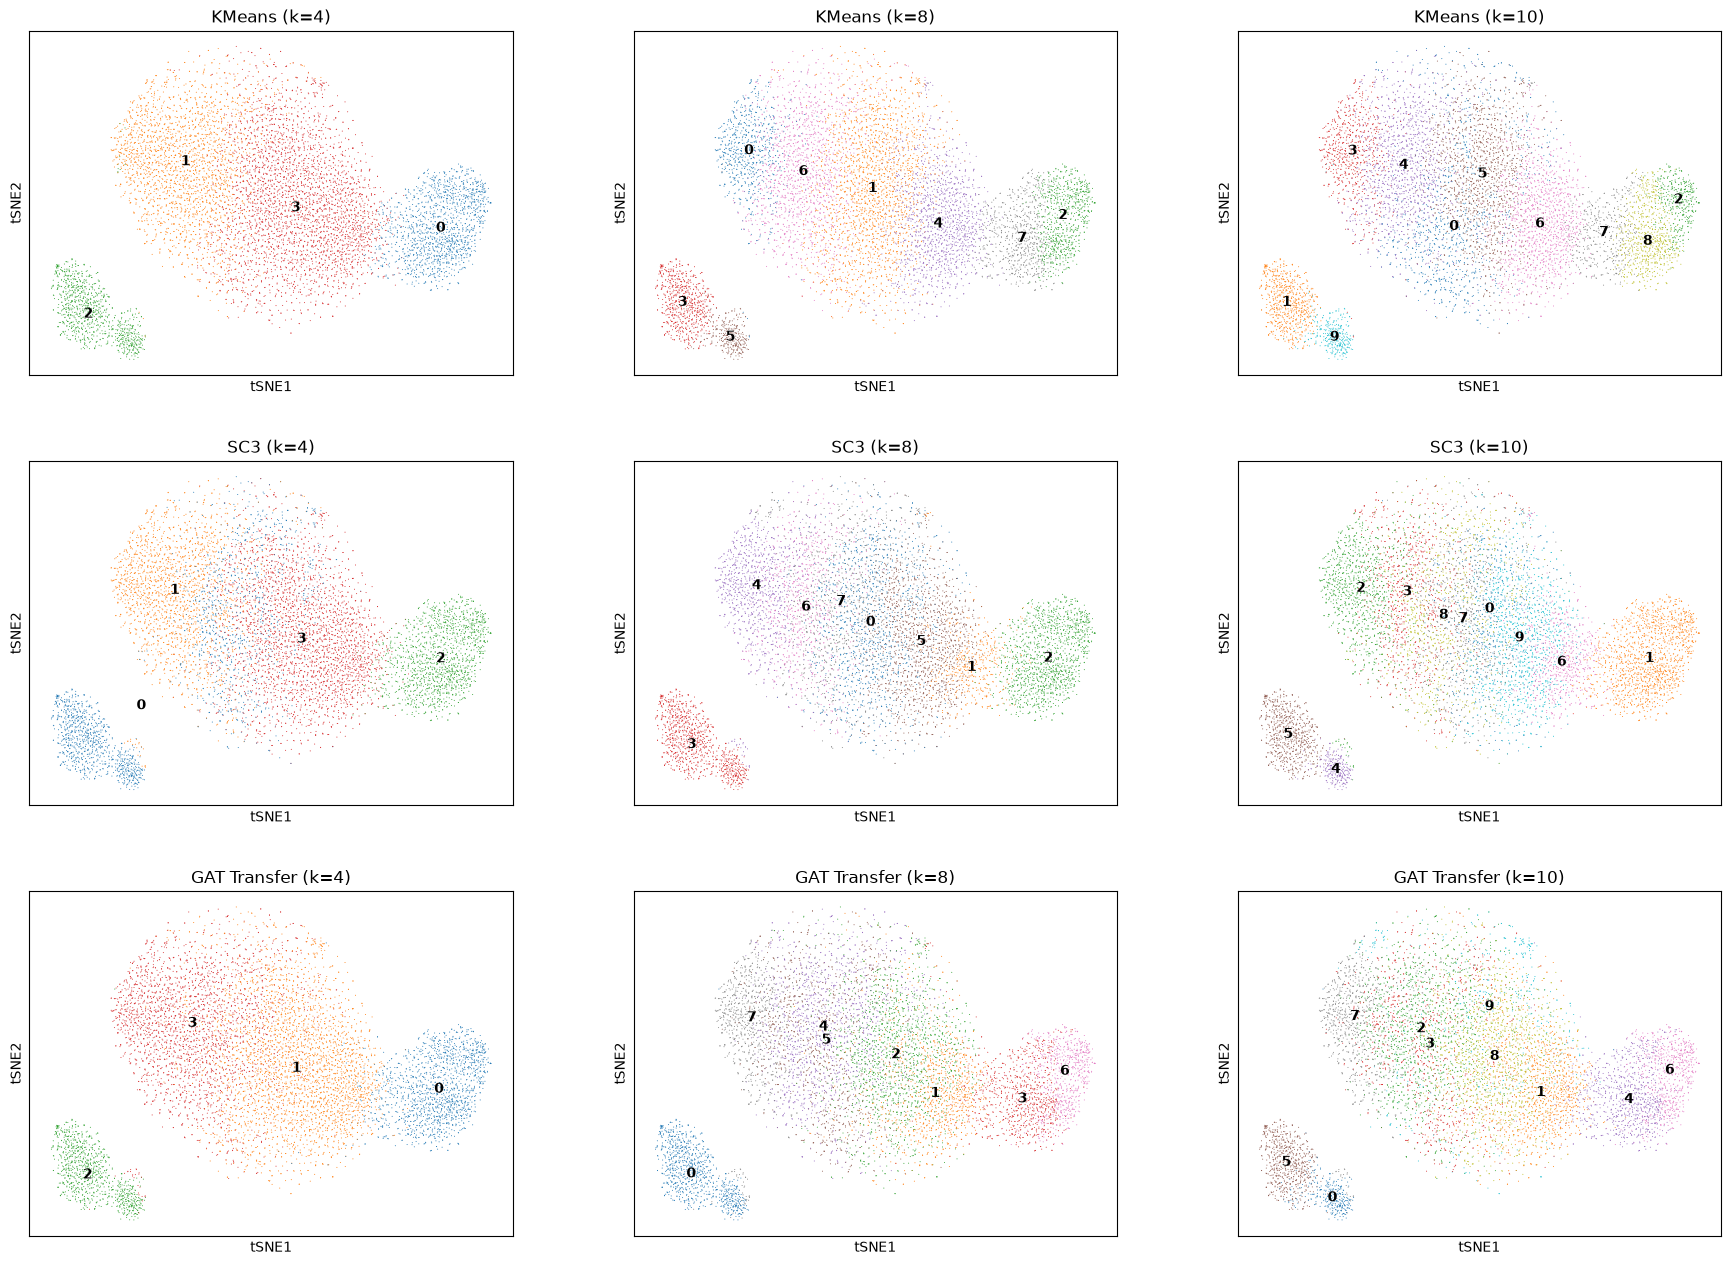

In [19]:
# ============================================================
# Visualize Klein clustering under noise — 3x3 grid comparison
# ============================================================

# Compute t-SNE for the noisy data
klein_noisy.obsm["X_pca"] = np.ascontiguousarray(klein_noisy_pca)
sc.tl.tsne(klein_noisy, n_pcs=50)

# All methods on noisy t-SNE (top: KMeans, middle: SC3, bottom: GAT)
comparison_cols = [f"kmeans_k{k}" for k in k_values] + [f"sc3s_{k}" for k in k_values] + [f"gat_k{k}" for k in k_values]
plot_titles = (
    [f"KMeans (k={k})" for k in k_values] +
    [f"SC3 (k={k})" for k in k_values] +
    [f"GAT Transfer (k={k})" for k in k_values]
)

sc.pl.tsne(
    klein_noisy,
    color=comparison_cols,
    ncols=3, size=2, legend_loc="on data",
    title=plot_titles
)


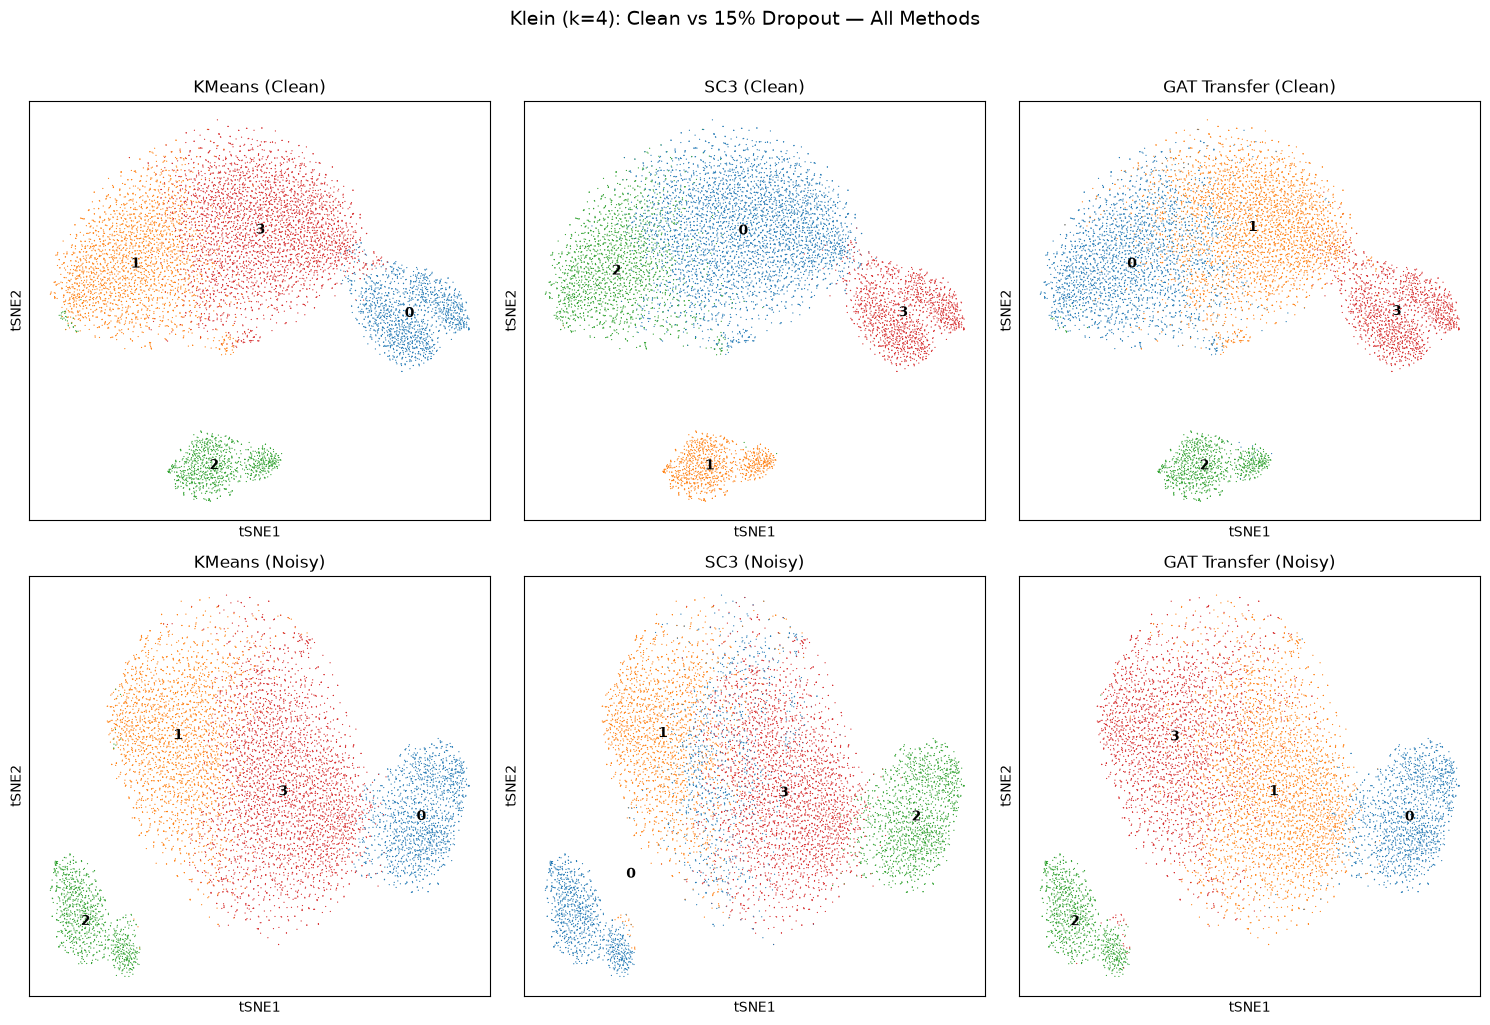

In [20]:
# ============================================================
# Clean vs Noisy t-SNE comparison (k=4, all methods)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: Clean
for ax, col, title in zip(axes[0], ["kmeans_k4", "sc3s_4", "gat_k4"],
                                     ["KMeans (Clean)", "SC3 (Clean)", "GAT Transfer (Clean)"]):
    sc.pl.tsne(klein_sub, color=col, ax=ax, show=False, size=3, title=title, legend_loc="on data")

# Bottom row: Noisy
for ax, col, title in zip(axes[1], ["kmeans_k4", "sc3s_4", "gat_k4"],
                                     ["KMeans (Noisy)", "SC3 (Noisy)", "GAT Transfer (Noisy)"]):
    sc.pl.tsne(klein_noisy, color=col, ax=ax, show=False, size=3, title=title, legend_loc="on data")

plt.suptitle("Klein (k=4): Clean vs 15% Dropout — All Methods", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# Clustering Stability (Clean vs Noisy)
# ============================================================

print("=" * 60)
print("KLEIN — Method Stability (Clean vs Noisy Clustering ARI)")
print("=" * 60)
print("How well each method reproduces its OWN clean clusters after noise is added.")
print(f"\n{'k':<4} {'Method':<18} {'Stability ARI':<15}")
print("-" * 40)

for k in k_values:
    for method, col in [("KMeans (PCA)", f"kmeans_k{k}"), ("SC3", f"sc3s_{k}"), ("GAT (Transfer)", f"gat_k{k}")]:
        # Calculate ARI between the method's clean predictions and its noisy predictions
        stability_ari = adjusted_rand_score(klein_sub.obs[col], klein_noisy.obs[col])
        print(f"{k:<4} {method:<18} {stability_ari:<15.4f}")
    print()

KLEIN — Method Stability (Clean vs Noisy Clustering ARI)
How well each method reproduces its OWN clean clusters after noise is added.

k    Method             Stability ARI  
----------------------------------------
4    KMeans (PCA)       0.8655         
4    SC3                0.6315         
4    GAT (Transfer)     0.7516         

8    KMeans (PCA)       0.7105         
8    SC3                0.5584         
8    GAT (Transfer)     0.5038         

10   KMeans (PCA)       0.4229         
10   SC3                0.4767         
10   GAT (Transfer)     0.4758         



In [22]:
# ============================================================
# Also validate GAT worked on training data (sanity check)
# ============================================================

# Zeisel clustering with GAT embeddings vs PCA
print("--- Training Set Validation (Zeisel, k=7) ---")
true_zeisel = zeisel_sub.obs["cell_type"]

km_pca = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_pca)
km_gat = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_gat)

print(f"  KMeans on PCA:  ARI = {adjusted_rand_score(true_zeisel, km_pca):.4f}")
print(f"  KMeans on GAT:  ARI = {adjusted_rand_score(true_zeisel, km_gat):.4f}")
print("\nIf GAT > PCA here, the model learned useful structure from the training data.")


--- Training Set Validation (Zeisel, k=7) ---
  KMeans on PCA:  ARI = 0.7902
  KMeans on GAT:  ARI = 0.7751

If GAT > PCA here, the model learned useful structure from the training data.
